## Problem Statement
Air pollution has become a critical environmental and public health issue, especially in rapidly urbanizing regions. The availability of real-time air quality data from multiple monitoring stations provides an opportunity to analyze pollution trends and predict air quality levels.

The objective of this project is to develop a machine learning model that can analyze historical air quality data and accurately predict pollutant levels or overall air quality conditions based on various environmental and geographical factors such as location, time, and pollutant measurements.

This project aims to:

Identify patterns and trends in air pollution across different cities and stations
Perform data preprocessing and feature engineering to enhance model performance
Build and compare multiple machine learning models to predict air quality indicators
Provide insights that can assist policymakers, environmental agencies, and the public in making informed decisions

By leveraging machine learning techniques, this system seeks to contribute to early warning systems and better air quality management strategies.

### Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Real_time_air_quality.csv')
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Eluru,"District Court, Eluru - APPCB",12-04-2026 12:00:00,16.711754,81.092095,PM2.5,50.0,68.0,57.0
1,India,Andhra_Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",12-04-2026 12:00:00,16.316553,80.413302,SO2,10.0,11.0,10.0
2,India,Andhra_Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",12-04-2026 12:00:00,16.316553,80.413302,OZONE,27.0,27.0,27.0
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",12-04-2026 12:00:00,14.465052,78.824187,PM10,58.0,78.0,73.0
4,India,Andhra_Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",12-04-2026 12:00:00,16.186555,81.132190,PM2.5,52.0,67.0,55.0


In [7]:
print('Shape:', df.shape)
print('Column:', df.columns)
print('Data types:', df.dtypes)

Shape: (943, 11)
Column: Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')
Data types: country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object


In [9]:
df.describe()


,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,943.000000,943.000000,922.000000,922.000000,922.000000
mean,24.792051,80.564797,25.475054,94.432755,48.398048
std,4.200904,5.408998,28.273519,104.355060,49.543638
min,13.204880,70.776774,1.000000,1.000000,1.000000
25%,22.368195,77.146793,6.000000,19.250000,12.000000
50%,25.619651,79.409230,15.000000,61.500000,31.000000
75%,28.571027,84.900510,33.000000,115.750000,66.000000
max,30.751462,94.636574,150.000000,492.000000,300.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        943 non-null    object 
 1   state          943 non-null    object 
 2   city           943 non-null    object 
 3   station        943 non-null    object 
 4   last_update    943 non-null    object 
 5   latitude       943 non-null    float64
 6   longitude      943 non-null    float64
 7   pollutant_id   943 non-null    object 
 8   pollutant_min  922 non-null    float64
 9   pollutant_max  922 non-null    float64
 10  pollutant_avg  922 non-null    float64
dtypes: float64(5), object(6)
memory usage: 81.2+ KB


In [13]:
(df.isna().sum()/len(df))*100

country          0.000000
state            0.000000
city             0.000000
station          0.000000
last_update      0.000000
latitude         0.000000
longitude        0.000000
pollutant_id     0.000000
pollutant_min    2.226935
pollutant_max    2.226935
pollutant_avg    2.226935
dtype: float64

In [15]:
df['pollutant_avg'] = df['pollutant_avg'].fillna(df['pollutant_avg'].median())
df['pollutant_min'] = df['pollutant_min'].fillna(df['pollutant_min'].median())
df['pollutant_max'] = df['pollutant_max'].fillna(df['pollutant_max'].median())

In [17]:
(df.isna().sum()/len(df))*100

country          0.0
state            0.0
city             0.0
station          0.0
last_update      0.0
latitude         0.0
longitude        0.0
pollutant_id     0.0
pollutant_min    0.0
pollutant_max    0.0
pollutant_avg    0.0
dtype: float64

In [19]:
df.drop_duplicates(inplace = True)

In [21]:
df.duplicated().sum()

0

In [23]:
df['last_update'] = pd.to_datetime(df['last_update'])

In [25]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ['country', 'state', 'city', 'station']
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = onehot_encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=onehot_encoder.get_feature_names_out(categorical_cols))
df_onehot = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
df_onehot.head()

,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,country_India,state_Andhra_Pradesh,state_Arunachal_Pradesh,...,"station_Talkatora Garden, Delhi - DPCC","station_Tarapur, Silchar - PCBA","station_Toll Gate, Tirumala - APPCB","station_Town Hall, Munger - BSPCB","station_Urja Nagar, Korba - CECB","station_Vaikuntapuram, Tirupati - APPCB","station_Vidhyanagar, Bhavnagar - Nexteng Enviro","station_Vivek Vihar, Delhi - DPCC","station_Wazirpur, Delhi - DPCC","station_Yerramukkapalli, Kadapa - APPCB"
0,2026-12-04 12:00:00,16.711754,81.092095,PM2.5,50.0,68.0,57.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-12-04 12:00:00,16.316553,80.413302,SO2,10.0,11.0,10.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-12-04 12:00:00,16.316553,80.413302,OZONE,27.0,27.0,27.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-12-04 12:00:00,14.465052,78.824187,PM10,58.0,78.0,73.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2026-12-04 12:00:00,16.186555,81.132190,PM2.5,52.0,67.0,55.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
from sklearn.preprocessing import MinMaxScaler
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df[numerical_cols]

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
0,0.199861,0.432331,0.328859,0.136456,0.187291
1,0.177338,0.403881,0.060403,0.020367,0.030100
2,0.177338,0.403881,0.174497,0.052953,0.086957
3,0.071819,0.337279,0.382550,0.156823,0.240803
4,0.169929,0.434011,0.342282,0.134420,0.180602
...,...,...,...,...,...
938,0.572120,0.080184,0.006711,0.089613,0.023411
939,0.592040,0.066892,0.006711,0.006110,0.006689
940,0.524656,0.097283,0.107383,0.511202,0.317726
941,0.515426,0.000000,0.281879,0.171079,0.217391


### EDA

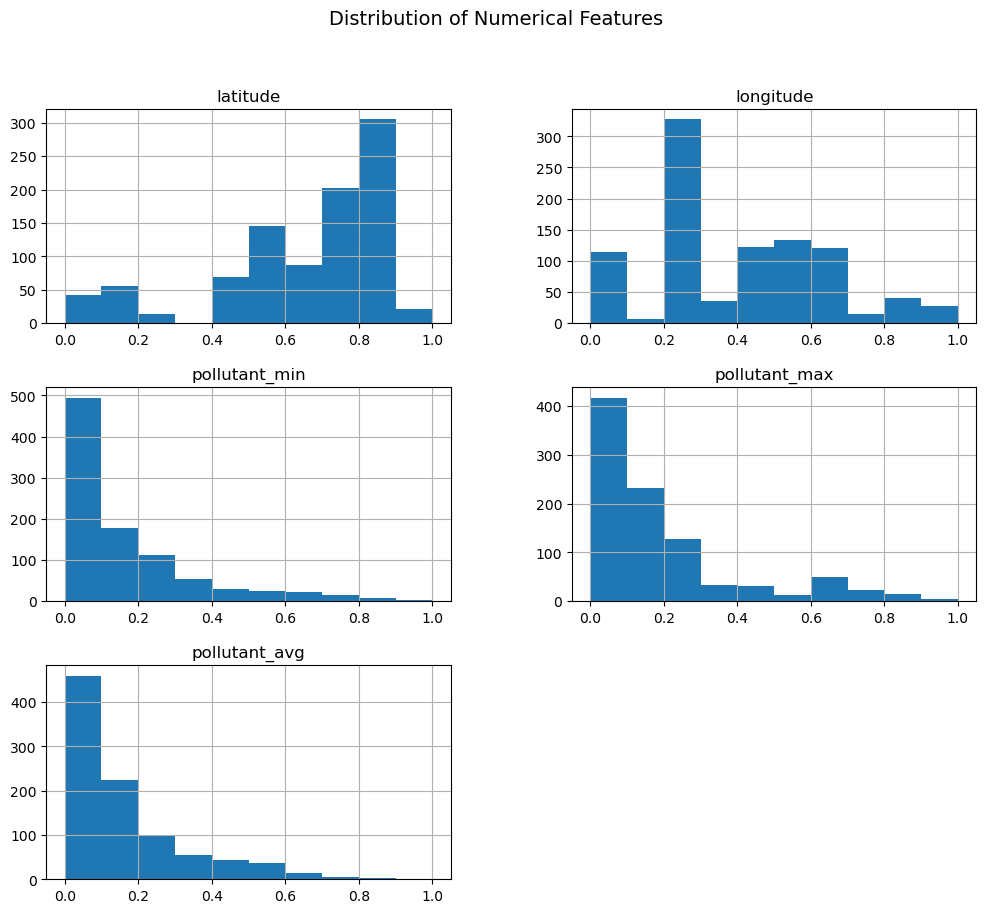

In [30]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[num_cols].hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

In [31]:
# Check unique values count
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))


Value counts for country:
country
India    943
Name: count, dtype: int64

Value counts for state:
state
Delhi                299
Bihar                228
Gujarat              121
Andhra_Pradesh       112
Chhattisgarh          94
Assam                 61
Chandigarh            21
Arunachal_Pradesh      7
Name: count, dtype: int64

Value counts for city:
city
Delhi          299
Ahmedabad       54
Patna           40
Vijayawada      28
Raipur          27
Guwahati        26
Bhilai          21
Gandhinagar     21
Chandigarh      21
Muzaffarpur     19
Name: count, dtype: int64

Value counts for station:
station
District Court, Eluru - APPCB              7
Sri Aurobindo Marg, Delhi - DPCC           7
Sector-10, Gandhinagar - GPCB              7
GIFT City, Gandhinagar - IITM              7
Vidhyanagar, Bhavnagar - Nexteng Enviro    7
SVPI Airport Hansol, Ahmedabad - IITM      7
SAC ISRO Bopal, Ahmedabad - IITM           7
Rakhial, Ahmedabad - IITM                  7
Raikhad, Ahmedabad - IITM    

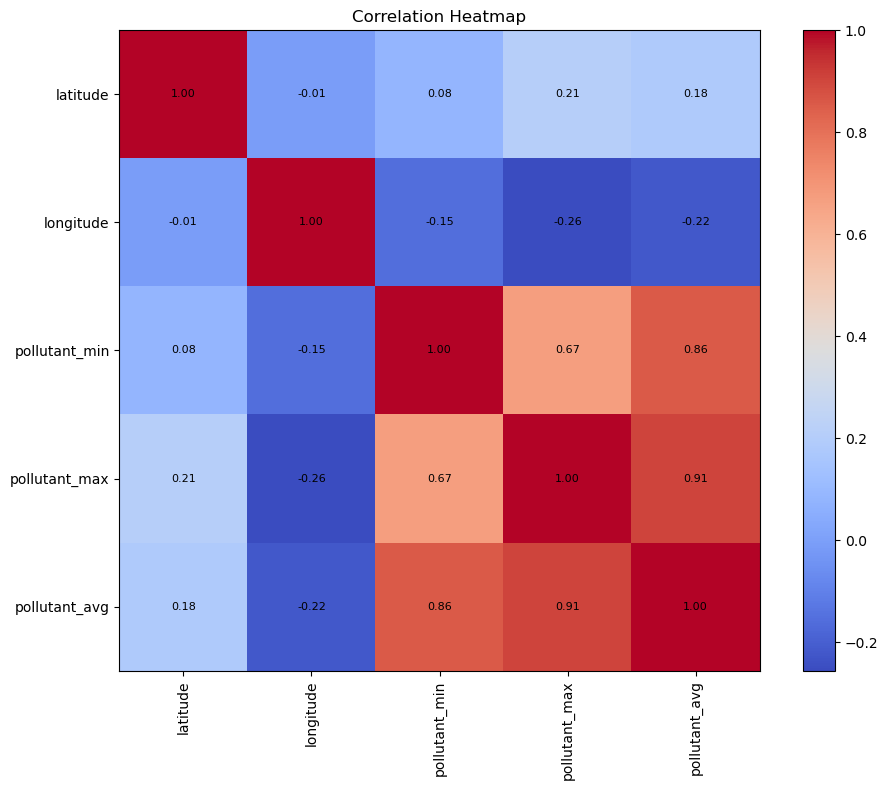

<Figure size 640x480 with 0 Axes>

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# values inside boxes
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.savefig("heatmap.png")

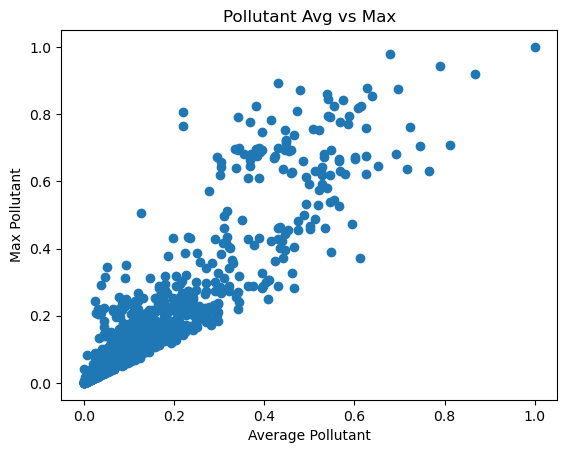

In [36]:
import matplotlib.pyplot as plt

# Example: Scatter plot between two important features
if 'pollutant_avg' in df.columns and 'pollutant_max' in df.columns:
    plt.figure()
    plt.scatter(df['pollutant_avg'], df['pollutant_max'])
    plt.xlabel("Average Pollutant")
    plt.ylabel("Max Pollutant")
    plt.title("Pollutant Avg vs Max")
    plt.show()

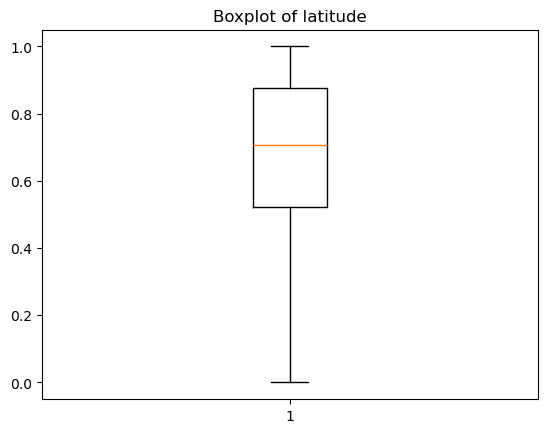

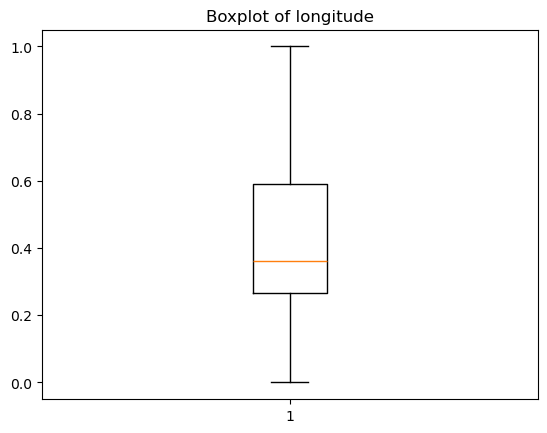

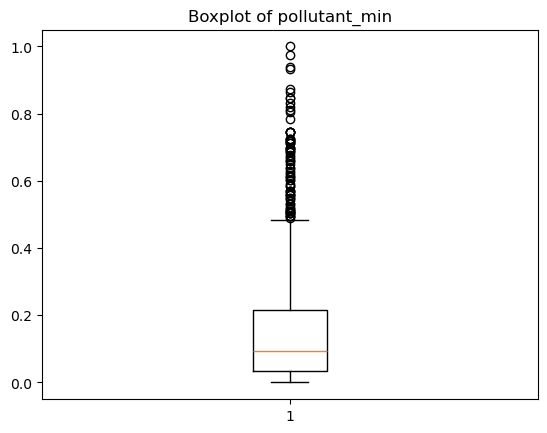

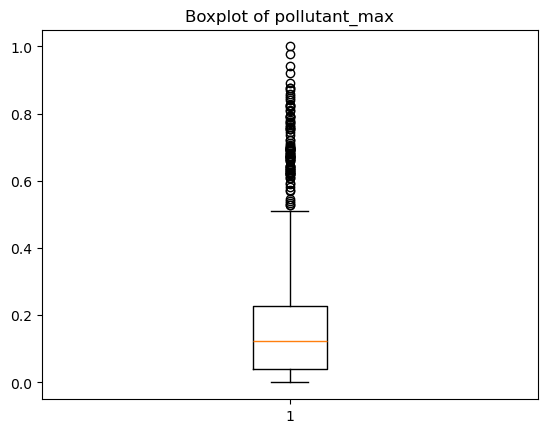

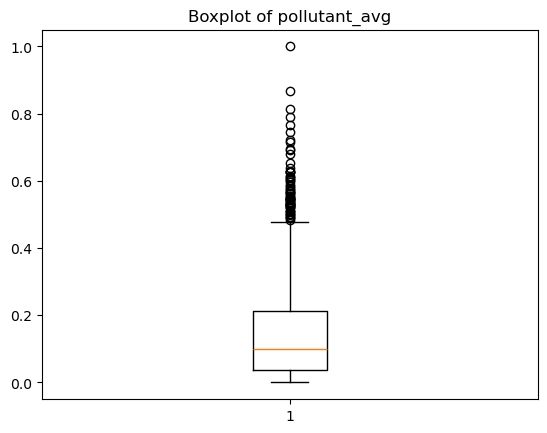

In [38]:
import matplotlib.pyplot as plt

# Boxplots for numerical features
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

### Feature Selection

In [41]:
target = 'pollutant_avg'

# Features and target split
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (943, 10)
Target shape: (943,)


In [43]:
# Keep only numeric columns for feature selection
X_numeric = X.select_dtypes(include=['int64', 'float64'])

print("Numeric features:")
print(X_numeric.columns)

Numeric features:
Index(['latitude', 'longitude', 'pollutant_min', 'pollutant_max'], dtype='object')


In [45]:
import numpy as np

# Compute correlation with target
corr_with_target = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

print("Correlation with target:")
print(corr_with_target)

# Select features with correlation > threshold
threshold = 0.3
selected_corr_features = corr_with_target[corr_with_target > threshold].index.tolist()

# Remove target itself
selected_corr_features.remove(target)

print("\nSelected Features (Correlation-based):")
print(selected_corr_features)

Correlation with target:
pollutant_avg    1.000000
pollutant_max    0.905872
pollutant_min    0.856264
longitude        0.217264
latitude         0.182465
Name: pollutant_avg, dtype: float64

Selected Features (Correlation-based):
['pollutant_max', 'pollutant_min']


In [47]:
from sklearn.feature_selection import SelectKBest, f_regression

# Initialize selector
selector = SelectKBest(score_func=f_regression, k=5)

# Fit selector
X_new = selector.fit_transform(X_numeric, y)

# Get selected feature names
selected_kbest_features = X_numeric.columns[selector.get_support()]

print("Selected Features (SelectKBest):")
print(selected_kbest_features)

Selected Features (SelectKBest):
Index(['latitude', 'longitude', 'pollutant_min', 'pollutant_max'], dtype='object')


C:\Users\Impana\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=5 is greater than n_features=4. All the features will be returned.
  warnings.warn(


In [49]:
from sklearn.ensemble import RandomForestRegressor

# Train model
model = RandomForestRegressor()
model.fit(X_numeric, y)

# Feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Ranking:")
display(feature_importance_df)

Feature Importance Ranking:


,Feature,Importance
3,pollutant_max,0.757383
2,pollutant_min,0.215071
0,latitude,0.014698
1,longitude,0.012848


### Train Test split

In [52]:
from sklearn.model_selection import train_test_split
target = 'pollutant_avg'   
X = df.drop(columns=[target])
y = df[target]
X = X.select_dtypes(include=['int64', 'float64'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    shuffle=True
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (754, 4)
X_test shape : (189, 4)
y_train shape: (754,)
y_test shape : (189,)


### Model Selection

#### Linear Regression

[0.00967835 0.40924865 0.06230442 0.18631604 0.11859289 0.09557748
 0.17150177 0.14232754 0.08953611 0.05459351 0.06231152 0.16948177
 0.08884036 0.06319195 0.40856548 0.07759275 0.07634038 0.10882841
 0.13516531 0.07060284 0.07843681 0.03706021 0.50870756 0.0711444
 0.03607303 0.0186899  0.0960458  0.03164506 0.0346481  0.543636
 0.04346371 0.10408358 0.08644626 0.01906095 0.33424546 0.29385948
 0.01812275 0.1634102  0.07290466 0.01796284 0.39062649 0.01098239
 0.27585152 0.0114064  0.53942424 0.22027281 0.04800897 0.42283982
 0.00503392 0.12419052 0.03411678 0.01836394 0.07381395 0.10194626
 0.18141411 0.04743772 0.46983374 0.12311675 0.0447625  0.21213376
 0.45584204 0.04003972 0.47781038 0.05376182 0.05907263 0.64251135
 0.58406973 0.03801945 0.26632814 0.54667785 0.1384998  0.32019829
 0.12921473 0.10134782 0.02859408 0.09902805 0.2847359  0.13287265
 0.31470577 0.00957428 0.11152381 0.16697132 0.00996861 0.71461559
 0.08389211 0.24975976 0.40466565 0.47728575 0.11592254 0.3946847

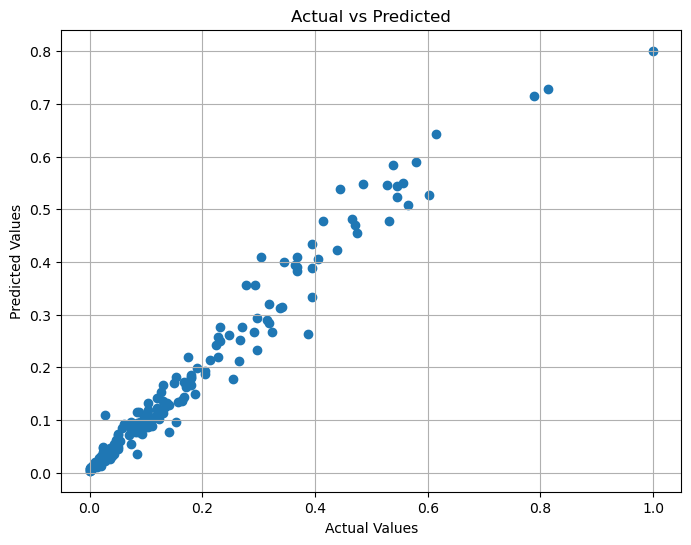

In [56]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
print(lr_predictions)

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

[0.01003344 0.52173913 0.05351171 0.20401338 0.09698997 0.13712375
 0.16722408 0.04347826 0.1270903  0.06688963]


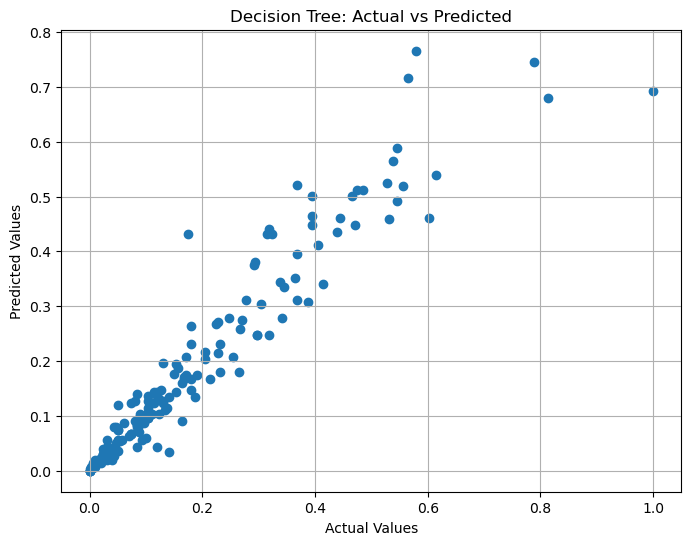

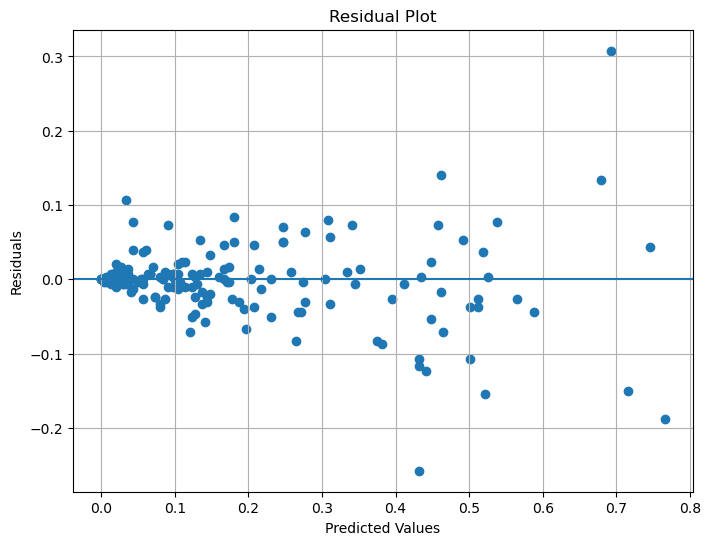

In [58]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
print(dt_predictions[:10])

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, dt_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)
plt.show()

residuals = y_test - dt_predictions

plt.figure(figsize=(8,6))
plt.scatter(dt_predictions, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0)
plt.grid(True)
plt.show()

Predictions: [0.01003344 0.50167224 0.05551839 0.17391304 0.13311037 0.10367893
 0.18528428 0.15183946 0.08494983 0.05819398]


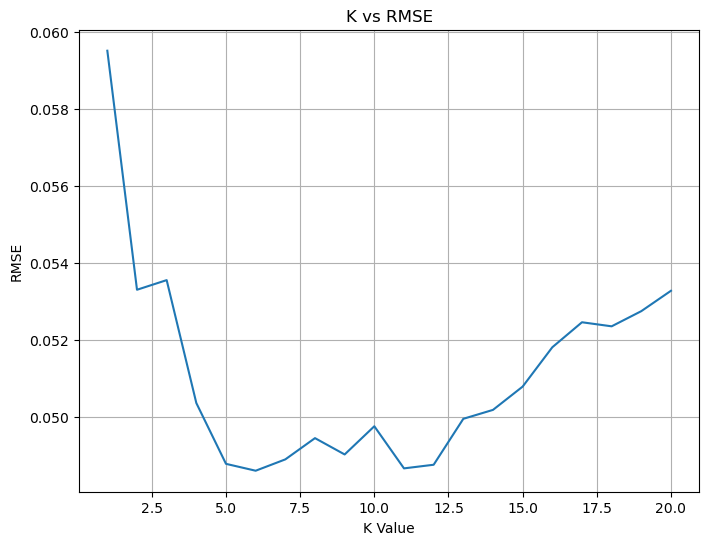

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = model_knn.predict(X_test_scaled)

print("Predictions:", y_pred_knn[:10])

# K vs RMSE
k_values = range(1, 21)
rmse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    rmse.append(np.sqrt(mean_squared_error(y_test, pred)))

# Plot
plt.figure(figsize=(8,6))
plt.plot(k_values, rmse)
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("K vs RMSE")
plt.grid(True)
plt.show()

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

model_gbr = GradientBoostingRegressor(random_state=42)
model_gbr.fit(X_train, y_train)

y_pred_gbr = model_gbr.predict(X_test)

print("Gradient Boosting Predictions:")
print(y_pred_gbr[:10])

Gradient Boosting Predictions:
[0.00969571 0.4938109  0.05527619 0.20069908 0.10874461 0.10069636
 0.1701876  0.1402602  0.09088871 0.06165552]


In [64]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Predictions:")
print(y_pred_rf[:10])

Random Forest Predictions:
[0.00625418 0.47056856 0.05230769 0.20036789 0.10464883 0.11180602
 0.16672241 0.12391304 0.09963211 0.06785953]


### Model Training & Testing

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
target = 'pollutant_avg'

# 🔹 Prepare features and target
X = df.drop(columns=[target]).select_dtypes(include=['int64', 'float64'])
y = df[target].loc[X.index]

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNeighbour Regressor":KNeighborsRegressor(n_neighbors = 5)
}

# 🔹 Train and Evaluate
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

# 🔹 Convert results to DataFrame
results_df = pd.DataFrame(results)

# 🔹 Display results
print("Model Performance Comparison:")
print(results_df.sort_values(by="R2 Score", ascending=False))

Model Performance Comparison:
                  Model       MAE      RMSE  R2 Score
0     Linear Regression  0.020155  0.032455  0.967068
2         Random Forest  0.021964  0.041919  0.945063
3     Gradient Boosting  0.023389  0.042126  0.944518
4  KNeighbour Regressor  0.026766  0.049829  0.922374
1         Decision Tree  0.028525  0.051762  0.916232


### Performance evaluation

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# 🔹 Initialize models
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)
knn_model = KNeighborsRegressor(n_neighbors=5)

# 🔹 Train models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

# 🔹 Predictions
lr_predictions = lr_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
gb_predictions = gb_model.predict(X_test)
knn_predictions = knn_model.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

results = []

models_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    models_predictions[name] = y_pred
for name, y_pred in models_predictions.items():
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values(by="R2 Score", ascending=False))

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.020155,0.001053,0.032455,0.967068
2,Random Forest,0.021964,0.001757,0.041919,0.945063
3,Gradient Boosting,0.023389,0.001775,0.042126,0.944518
4,KNeighbour Regressor,0.026766,0.002483,0.049829,0.922374
1,Decision Tree,0.028525,0.002679,0.051762,0.916232


### Hyperparameter tuning

In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Model
rf = RandomForestRegressor(random_state=42)

# Parameter grid
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Fit
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

print("Best Parameters (Random Forest):")
print(grid_rf.best_params_)

Best Parameters (Random Forest):
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
